# LightGBM for Wind Power Forecasting

This notebook trains and evaluates a LightGBM regressor to predict wind farm `capacity_factor`.

(Follows the same structure as `xgboost_wind_model.py` )

We rely on:
- precomputed train/test parquet files
- shared utilities from `utils.py`
- time-based expanding-window cross-validation

Main sections 

1. Load prepared datasets
2. Build temporal CV folds
3. Train/validate LightGBM with early stopping
4. Evaluate on the held-out test set

## 0. Set UP 


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import lightgbm as lgb

from utils import (
    load_data,
    get_cv_folds,
    evaluate,
    plot_forecast,
    plot_forecast_zoom,
)

## 1. Load preprocessed datasets

We load:
- training and test feature matrices
- target vectors
- metadata (time, site, installed capacity)
- site mapping

The metadata is required for:
- rebuilding temporal folds
- per-site evaluation
- plotting forecasts

In [2]:
X_train, y_train, X_test, y_test, meta_train, meta_test, site_mapping = load_data()

X_train : (248304, 77)  |  X_test : (26390, 77)
Train period : 2023-01-01 → 2025-10-31
Test  period : 2025-11-01 → 2026-02-18
Sites : 10


We verify that:
- train and metadata have aligned lengths
- test and metadata have aligned lengths
- delivery times are chronologically sorted

In [3]:
assert len(X_train) == len(y_train) == len(meta_train)
assert meta_train["delivery_time"].is_monotonic_increasing
print(f"X_train: {X_train.shape} | X_test: {X_test.shape}")

X_train: (248304, 77) | X_test: (26390, 77)


## 2. Time-based cross-validation

In [4]:
folds = get_cv_folds(meta_train["delivery_time"])

CV: 6 folds | val window = 90 days | expanding train
  Fold 1: train 2023-01-01 → 2024-05-09  |  val 2024-05-09 → 2024-08-07  (118,790 / 21,552 rows)
  Fold 2: train 2023-01-01 → 2024-08-07  |  val 2024-08-07 → 2024-11-05  (140,342 / 21,600 rows)
  Fold 3: train 2023-01-01 → 2024-11-05  |  val 2024-11-05 → 2025-02-03  (161,942 / 21,600 rows)
  Fold 4: train 2023-01-01 → 2025-02-03  |  val 2025-02-03 → 2025-05-04  (183,542 / 21,552 rows)
  Fold 5: train 2023-01-01 → 2025-05-04  |  val 2025-05-04 → 2025-08-02  (205,094 / 21,600 rows)
  Fold 6: train 2023-01-01 → 2025-08-02  |  val 2025-08-02 → 2025-10-31  (226,694 / 21,600 rows)


## 3. LightGBM Configuration
We use a GOSS (Gradient-based One-Side Sampling) or traditional 'gbdt' approach with 
regularization parameters similar to the XGBoost setup.

In [5]:
lgbm_params = {
    "objective": "regression",
    "metric": "rmse",
    "boosting_type": "gbdt",
    "n_estimators": 5000,
    "learning_rate": 0.02,
    "max_depth": 4,
    "num_leaves": 15,          # Roughly 2^(max_depth)-1
    "min_child_samples": 20,
    "subsample": 0.7,
    "colsample_bytree": 0.6,
    "reg_alpha": 1.0,
    "reg_lambda": 5.0,
    "random_state": 42,
    "n_jobs": -1,
    "verbosity": -1
}

## 4. Cross validation training 

In [6]:
cv_rows = []
oof_pred = np.full(len(X_train), np.nan)
best_iterations = []

for fold_id, (tr_idx, val_idx) in enumerate(folds, start=1):
    X_tr, y_tr = X_train.iloc[tr_idx], y_train.iloc[tr_idx]
    X_val, y_val = X_train.iloc[val_idx], y_train.iloc[val_idx]

    model = lgb.LGBMRegressor(**lgbm_params)

    model.fit(
        X_tr, y_tr,
        eval_set=[(X_val, y_val)],
        callbacks=[
            lgb.early_stopping(stopping_rounds=100),
            lgb.log_evaluation(period=0) # Silent
        ]
    )

    best_iter = model.best_iteration_
    best_iterations.append(best_iter)

    pred_val = model.predict(X_val, num_iteration=best_iter)
    oof_pred[val_idx] = pred_val

    metrics, _ = evaluate(
        y_true=y_val,
        y_pred=pred_val,
        site_names=meta_train.iloc[val_idx]["site_name"].values,
        model_name=f"LightGBM CV Fold {fold_id}"
    )

    cv_rows.append({
        "split": f"CV Fold {fold_id}",
        "MAE": metrics["MAE"],
        "RMSE": metrics["RMSE"],
        "nRMSE": metrics["nRMSE"],
        "best_iteration": best_iter,
    })

Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[1088]	valid_0's rmse: 0.0801805
[LightGBM CV Fold 1]  Global — MAE=0.0505  RMSE=0.0802  nRMSE=0.0810  (n=21,552)
                                     MAE    RMSE   nRMSE     n
site                                                          
Mermaid Offshore WP               0.0615  0.1016  0.1034  2160
Seastar Offshore WP               0.0603  0.0936  0.0948  2160
Norther Offshore WP               0.0594  0.0900  0.0957  2136
Northwester 2                     0.0478  0.0806  0.0899  2160
Nobelwind Offshore Windpark       0.0515  0.0804  0.0832  2160
Rentel Offshore WP                0.0483  0.0750  0.0758  2136
Thorntonbank - C-Power - Area SW  0.0464  0.0730  0.0751  2160
Northwind                         0.0472  0.0705  0.0731  2160
Thorntonbank - C-Power - Area NE  0.0422  0.0644  0.0686  2160
Belwind Phase 1                   0.0405  0.0640  0.0673  2160
Training until validation scores 

In [7]:
cv_results_df = pd.DataFrame(cv_rows)
display(cv_results_df)

oof_metrics, oof_per_site = evaluate(
    y_true=y_train[~np.isnan(oof_pred)],
    y_pred=oof_pred[~np.isnan(oof_pred)],
    site_names=meta_train.iloc[~np.isnan(oof_pred)]["site_name"].values,
    model_name="LightGBM OOF CV"
)
print(f"OOF Global RMSE: {oof_metrics['RMSE']:.4f}")

,split,MAE,RMSE,nRMSE,best_iteration
0,CV Fold 1,0.050507,0.080180,0.081036,1088
1,CV Fold 2,0.065078,0.104263,0.105347,1877
2,CV Fold 3,0.055886,0.084770,0.085557,801
3,CV Fold 4,0.054634,0.082540,0.083447,1782
4,CV Fold 5,0.066214,0.102683,0.103824,1093
5,CV Fold 6,0.066632,0.098344,0.099327,684


[LightGBM OOF CV]  Global — MAE=0.0598  RMSE=0.0927  nRMSE=0.0935  (n=129,504)
                                     MAE    RMSE   nRMSE      n
site                                                           
Norther Offshore WP               0.0681  0.1087  0.1120  12936
Mermaid Offshore WP               0.0679  0.1032  0.1048  12960
Northwester 2                     0.0651  0.1013  0.1032  12960
Seastar Offshore WP               0.0651  0.0960  0.0971  12960
Nobelwind Offshore Windpark       0.0603  0.0931  0.0943  12960
Rentel Offshore WP                0.0584  0.0900  0.0908  12936
Northwind                         0.0574  0.0874  0.0887  12936
Thorntonbank - C-Power - Area SW  0.0537  0.0838  0.0851  12960
Thorntonbank - C-Power - Area NE  0.0526  0.0812  0.0829  12936
Belwind Phase 1                   0.0496  0.0768  0.0793  12960
OOF Global RMSE: 0.0927


## 5. Training on full training set

In [8]:
avg_best_iter = int(np.mean(best_iterations))
print(f"Training on full set with {avg_best_iter} iterations...")

final_model = lgb.LGBMRegressor(**{**lgbm_params, "n_estimators": avg_best_iter})
final_model.fit(X_train, y_train)

test_pred = final_model.predict(X_test)
test_metrics, test_per_site = evaluate(
    y_true=y_test,
    y_pred=test_pred,
    site_names=meta_test["site_name"].values,
    model_name="LightGBM Final Test"
)

Training on full set with 1220 iterations...
[LightGBM Final Test]  Global — MAE=0.0733  RMSE=0.1025  nRMSE=0.1034  (n=26,390)
                                     MAE    RMSE   nRMSE     n
site                                                          
Northwester 2                     0.1004  0.1313  0.1336  2639
Norther Offshore WP               0.0788  0.1068  0.1101  2639
Mermaid Offshore WP               0.0773  0.1062  0.1079  2639
Northwind                         0.0695  0.0988  0.1002  2639
Nobelwind Offshore Windpark       0.0684  0.0972  0.0984  2639
Seastar Offshore WP               0.0716  0.0969  0.0981  2639
Thorntonbank - C-Power - Area NE  0.0670  0.0967  0.0987  2639
Thorntonbank - C-Power - Area SW  0.0671  0.0956  0.0970  2639
Rentel Offshore WP                0.0668  0.0953  0.0961  2639
Belwind Phase 1                   0.0663  0.0946  0.0985  2639


## 6. Feature Importance

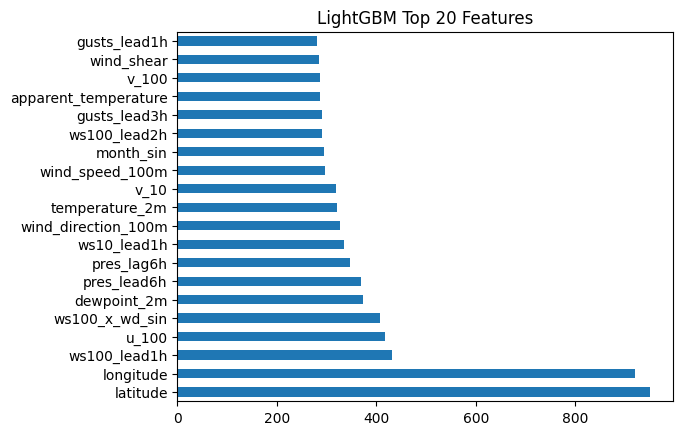

In [9]:
feat_imp = pd.Series(final_model.feature_importances_, index=X_train.columns)
feat_imp.nlargest(20).plot(kind='barh', title='LightGBM Top 20 Features')
plt.show()

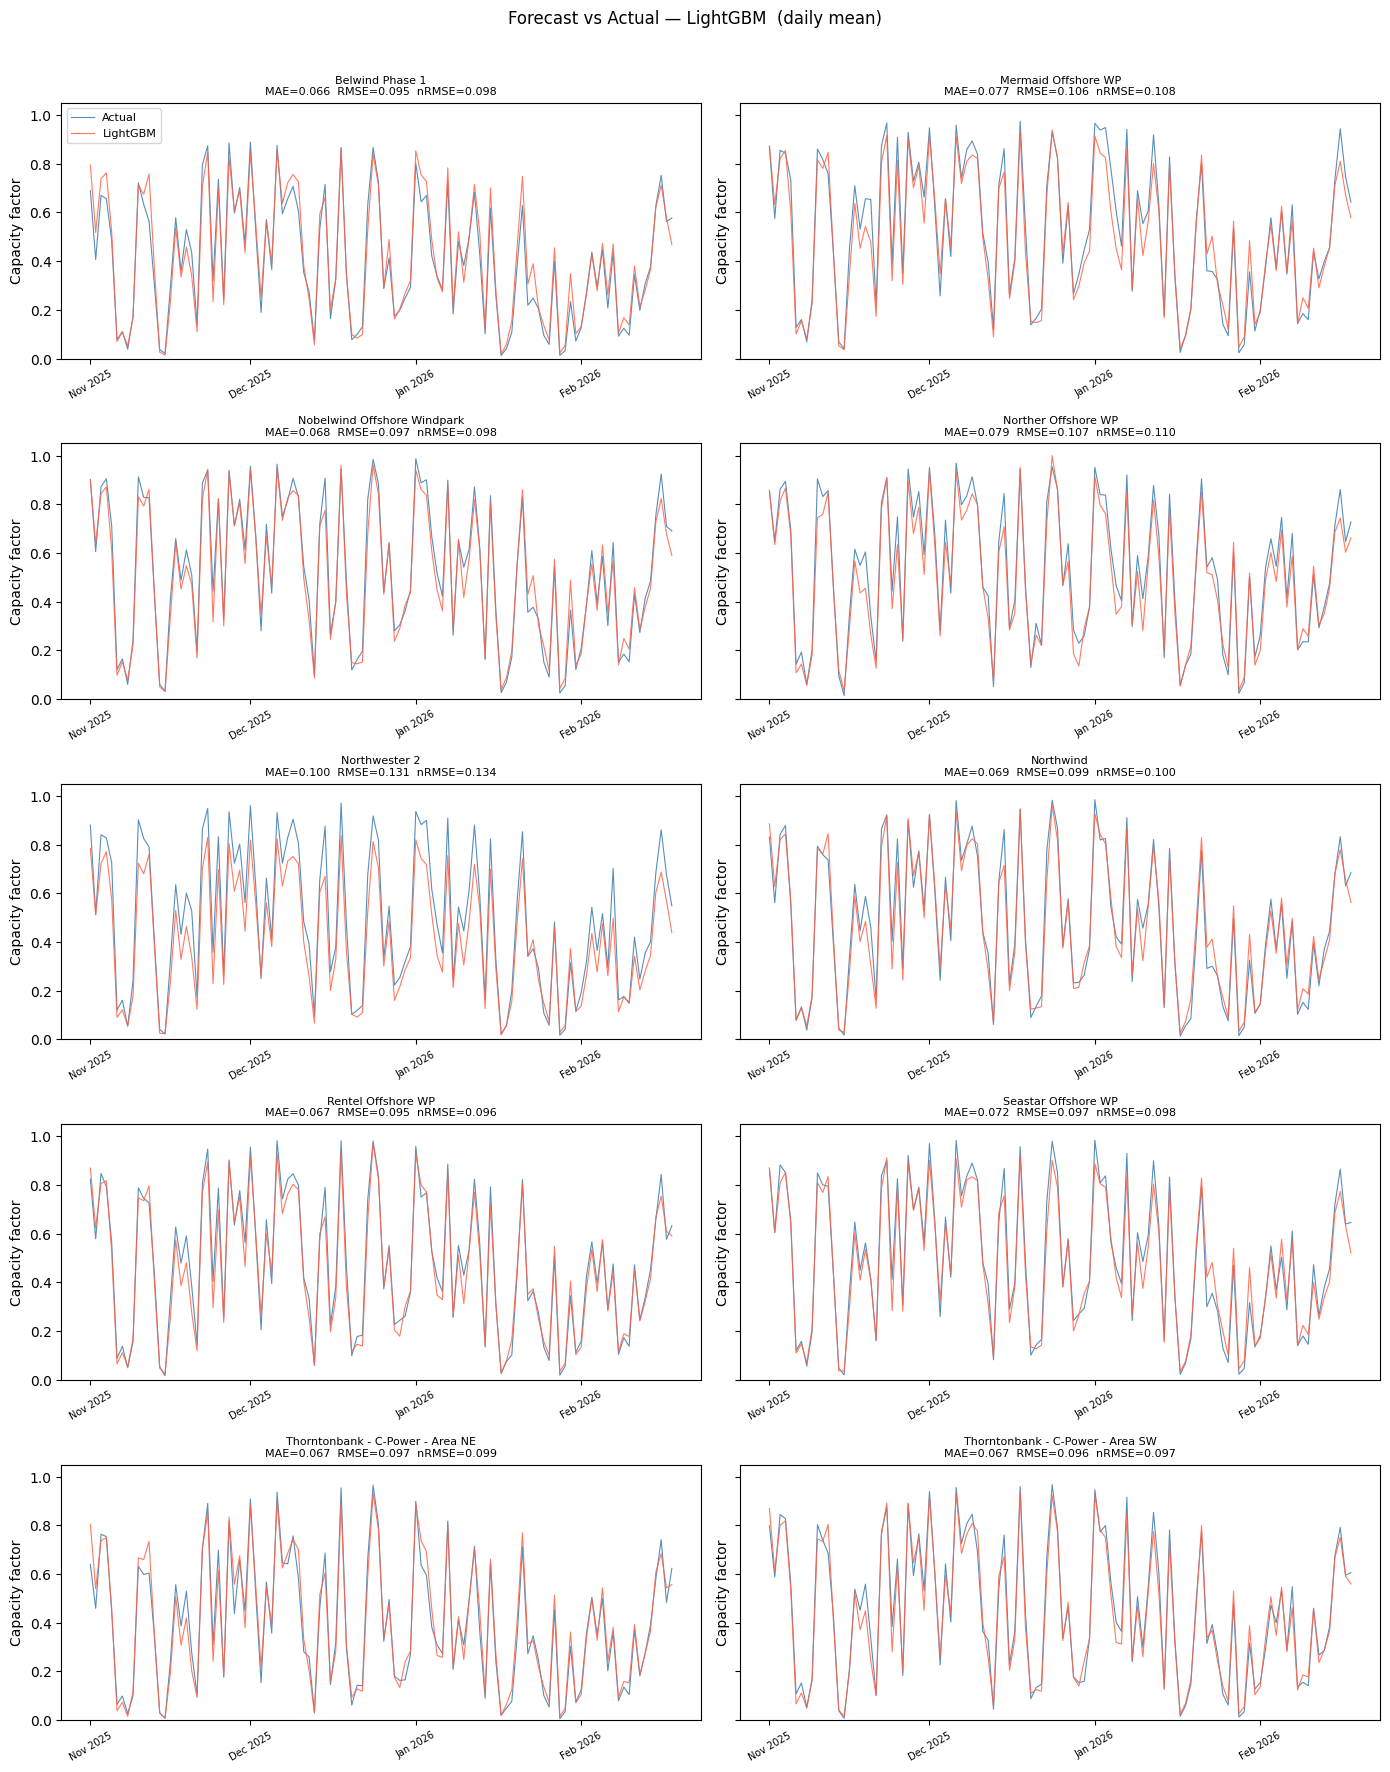

In [ ]:

test_pred = final_model.predict(X_test) 

plot_forecast(
    delivery_times=meta_test["delivery_time"].values, 
    y_true=y_test.values,                             
    y_pred=test_pred,                                
    site_names=meta_test["site_name"].values,         
    model_name="LightGBM"
)

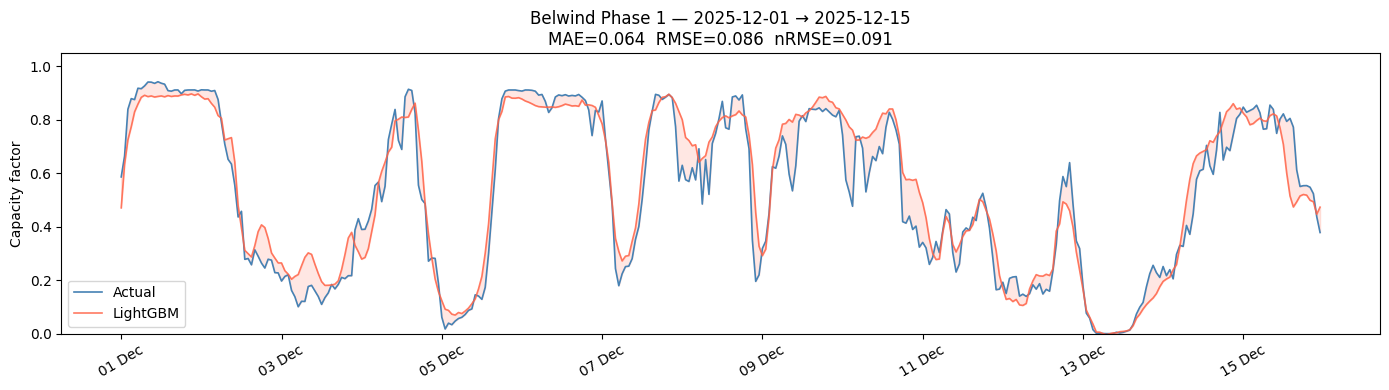

In [16]:
example_site = sorted(meta_test["site_name"].unique())[0]

plot_forecast_zoom(
    delivery_times=meta_test["delivery_time"],
    y_true=y_test,
    y_pred=test_pred,
    site_names=meta_test["site_name"],
    site=example_site,
    start="2025-12-01",
    end="2025-12-15",
    model_name="LightGBM",
)

In [18]:
import joblib

# Save the model
joblib.dump(final_model, './models/lgbm_wind_model.pkl')

# # To load it back
# loaded_model = joblib.load('./models/lgbm_wind_model.pkl')

# # Use it normally
# predictions = loaded_model.predict(X_test)

['./models/lgbm_wind_model.pkl']